# Linear Regression on Student_Performance dataset

In [70]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('Student_Performance.csv')

In [72]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [74]:
df.duplicated().sum()

np.int64(127)

In [75]:
df.drop_duplicates(inplace = True)

In [76]:
df.duplicated().sum()

np.int64(0)

duplicate values removed

<Axes: xlabel='Hours Studied'>

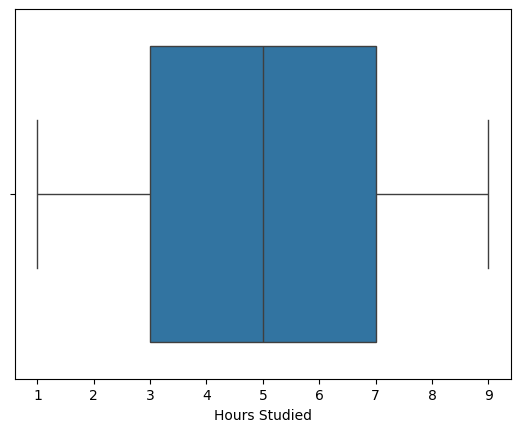

In [77]:
sns.boxplot(df,x='Hours Studied')

<Axes: xlabel='Previous Scores'>

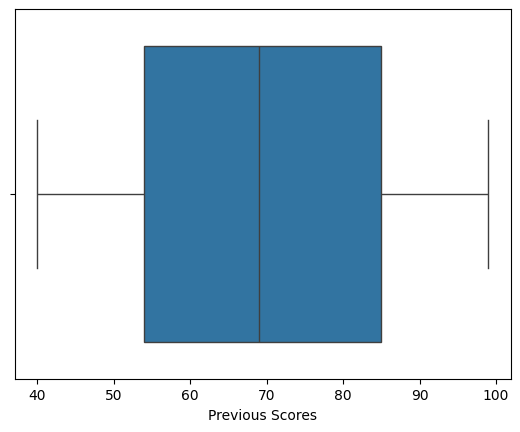

In [78]:
sns.boxplot(df,x='Previous Scores')

<Axes: xlabel='Sleep Hours'>

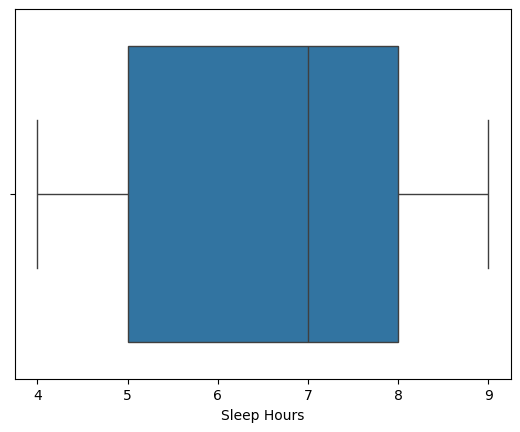

In [79]:
sns.boxplot(df,x='Sleep Hours')

<Axes: xlabel='Sample Question Papers Practiced'>

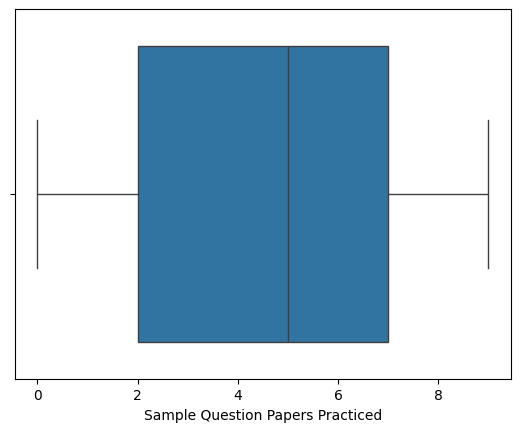

In [80]:
sns.boxplot(df,x='Sample Question Papers Practiced')

<Axes: xlabel='Performance Index'>

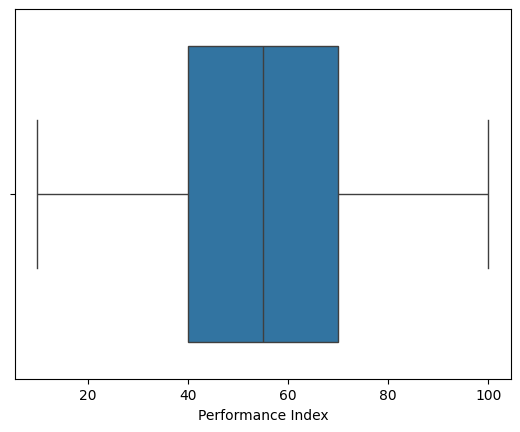

In [81]:
sns.boxplot(df,x='Performance Index')

we did not find any significant outliers

In [82]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

Now we encoded `Extracurricular Activities` in to 0 and 1

In [83]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [84]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].apply(lambda x: 1 if x=='Yes' else 0)

In [85]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
0    4986
1    4887
Name: count, dtype: int64

In [86]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


Performance Index is highly co-related with the Previous Scores

In [88]:
X = df.drop('Performance Index', axis = 1)
y = df['Performance Index']

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [91]:
model.coef_

array([2.8510219 , 1.01843034, 0.57382297, 0.47207329, 0.18870366])

In [92]:
model.intercept_

np.float64(-33.981324496440706)

In [93]:
y_pred_train = model.predict(X_train)

In [94]:
from sklearn.metrics import mean_squared_error,r2_score

In [95]:
mean_squared_error(y_train,y_pred_train)

4.144574536244127

In [96]:
r2_score(y_train,y_pred_train)

0.9887391160677558

In [97]:
y_pred_test= model.predict(X_test)

In [98]:
mean_squared_error(y_test,y_pred_test)

4.305900938538477

In [99]:
r2_score(y_test,y_pred_test)

0.9884301209927054